# Goal
The purpose of this notebook is to illustrate, using an example, four numerical methods for finding the roots of an equation in one variable. Furthermore, we compare the speed of convergence of these methods.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from numerical_methods import bisection, newton, regula_falsi, secant

How to use, e.g., the bisection function:

In [2]:
bisection?

Signature:
bisection(
    f: Callable[[float], float],
    a: int | float,
    b: int | float,
    tol: float = 1e-07,
    max_iter: int = 100,
) -> list[float]
Docstring:
Solve f(x) = 0 using the bisection method.

Parameters
----------
f : Callable[[float], float]
    The function for which we want to find a root.
a : int|float
    Left endpoint of the interval.
b : int|float
    Right endpoint of the interval.
tol : float, optional
    Desired tolerance (default is 1e-7).
max_iter : int, optional
    Maximum number of iterations (default is 100).

Returns
-------
list of float
    Estimates of the root at each iteration.

Raises
------
ValueError
    If f(a) and f(b) do not have opposite signs.
UserWarning
    If maximum iterations are reached without achieving the desired tolerance.

Example
-------
>>> f = lambda x: x**2 - 2
>>> bisection(f, 0, 2)
[1.0, 1.5, 1.25, ...]  # intermediate estimates
File:      c:\users\pavel\desktop\moje_mini_projekty\equation_solver\numerical_methods\

## Illustrative Example

**Task:**

Solve numerically the following equation with an accuracy of at least 8 correct decimal places:
$$
x^2 = 2
$$

**Hint:**

Reformulate the problem as finding the zero(s) of the function:
$$
f(x) = x^2 - 2
$$
and determine the value(s) of $x$ satisfying $f(x) = 0$.

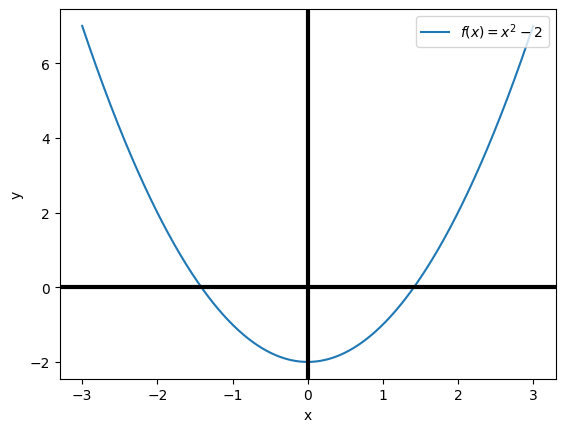

In [3]:
f = lambda x: x**2 - 2

x_range = np.linspace(-3,3,1000)
y_range = f(x_range)

plt.plot(x_range, y_range, label = r"$f(x) = x^2 - 2$")
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(y=0, color='black', linestyle='-', linewidth=3)
plt.axvline(x=0, color='black', linestyle='-', linewidth=3)
plt.legend(loc = "upper right")
plt.show()

**Bisection method**

In [4]:
x_bl = bisection(f = f, a = -2, b = -1, tol = 1e-8) 
x_br = bisection(f = f, a = 1,  b = 2,  tol = 1e-8)

print("Left:", round(x_bl[-1], 8),"\nRight:", round(x_br[-1], 8))

Left: -1.41421356 
Right: 1.41421356


**Newton method**

In [5]:
f_prime = lambda x: 2 * x

In [6]:
x_nl = newton(f = f, f_prime = f_prime, x0 = -2, tol = 1e-8) 
x_nr = newton(f = f, f_prime = f_prime, x0 = 2, tol = 1e-8) 

print("Left:", round(x_nl[-1], 8),"\nRight:", round(x_nr[-1], 8))

Left: -1.41421356 
Right: 1.41421356


**Regula falsi method**

In [7]:
x_rfl = regula_falsi(f = f, a = -2, b = -1, tol = 1e-8) 
x_rfr = regula_falsi(f = f, a = 1,  b = 2,  tol = 1e-8) 

print("Left:", round(x_rfl[-1], 8),"\nRight:", round(x_rfr[-1], 8))

Left: -1.41421356 
Right: 1.41421356


**Secant method**

In [8]:
x_sl = secant(f = f, x0 = -2, x1 = -1, tol = 1e-8) 
x_sr = secant(f = f, x0 = 1,  x1 = 2,  tol = 1e-8) 

print("Left:", round(x_sl[-1], 8),"\nRight:", round(x_sr[-1], 8))

Left: -1.41421356 
Right: 1.41421356


**Comparison between methods**

In [9]:
# left roots
delta_x_bl  = [abs(x_bl[i] - x_bl[i-1])   for i in range(1, len(x_bl))]
delta_x_nl  = [abs(x_nl[i] - x_nl[i-1])   for i in range(1, len(x_nl))]
delta_x_rfl = [abs(x_rfl[i] - x_rfl[i-1]) for i in range(1, len(x_rfl))]
delta_x_sl  = [abs(x_sl[i] - x_sl[i-1])   for i in range(1, len(x_sl))]

# right roots
delta_x_br  = [abs(x_br[i] - x_br[i-1])   for i in range(1, len(x_br))]
delta_x_nr  = [abs(x_nr[i] - x_nr[i-1])   for i in range(1, len(x_nr))]
delta_x_rfr = [abs(x_rfr[i] - x_rfr[i-1]) for i in range(1, len(x_rfr))]
delta_x_sr  = [abs(x_sr[i] - x_sr[i-1])   for i in range(1, len(x_sr))]

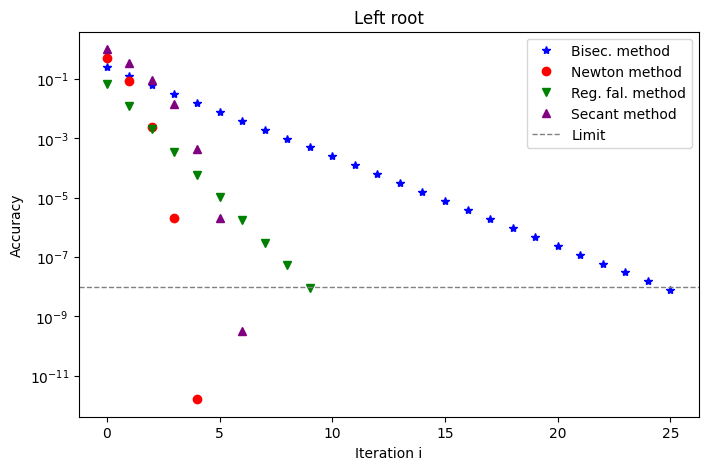

In [10]:
plt.figure(figsize = (8,5))

plt.plot(delta_x_bl, "*", color = "blue", label = "Bisec. method")
plt.plot(delta_x_nl, "o", color = "red", label = "Newton method")
plt.plot(delta_x_rfl, "v", color = "green", label = "Reg. fal. method")
plt.plot(delta_x_sl, "^", color = "purple", label = "Secant method")

plt.title("Left root")
plt.xlabel("Iteration i")
plt.ylabel("Accuracy")
plt.yscale('log')
plt.axhline(y=1e-8, color='grey', linestyle='--', linewidth=1, label = "Limit")
plt.legend()
plt.show()

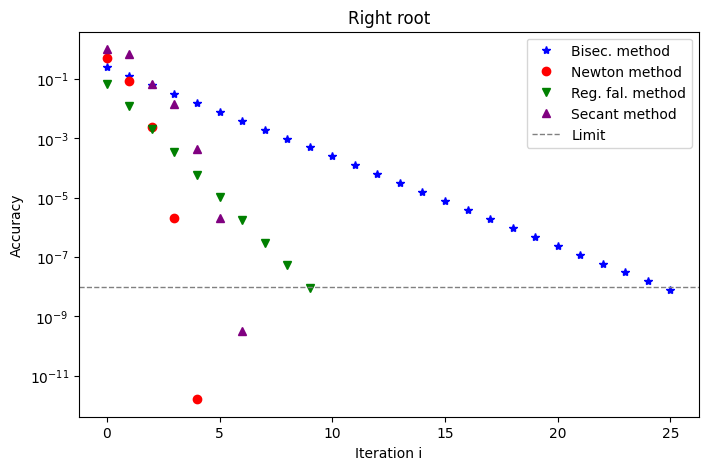

In [11]:
plt.figure(figsize = (8,5))

plt.plot(delta_x_br, "*", color = "blue", label = "Bisec. method")
plt.plot(delta_x_nr, "o", color = "red", label = "Newton method")
plt.plot(delta_x_rfr, "v", color = "green", label = "Reg. fal. method")
plt.plot(delta_x_sr, "^", color = "purple", label = "Secant method")

plt.title("Right root")
plt.xlabel("Iteration i")
plt.ylabel("Accuracy")
plt.yscale('log')
plt.axhline(y=1e-8, color='grey', linestyle='--', linewidth=1, label = "Limit")
plt.legend()
plt.show()

**Fitting the curves**

In [12]:
# bisection and regula falsi - linear dependence on iteration index
input_bl = range(0, len(delta_x_bl))
log_y_bl = np.log10(delta_x_bl)

input_rfl = range(0, len(delta_x_rfl))
log_y_rfl = np.log10(delta_x_rfl)

# newton and secant - quadratic dependence on iteration index
i_nl = range(0, len(delta_x_nl))
input_nl = np.array(i_nl)**2
log_y_nl = np.log10(delta_x_nl)

i_sl = range(0, len(delta_x_sl))
input_sl = np.array(i_sl)**2
log_y_sl = np.log10(delta_x_sl)

In [13]:
from scipy.stats import linregress

In [14]:
# fit
slope_bl, intercept_bl, r_value_bl, p_value_bl, std_err_bl = linregress(input_bl, log_y_bl)
slope_rfl, intercept_rfl, r_value_rfl, p_value_rfl, std_err_rfl = linregress(input_rfl, log_y_rfl)
slope_nl, intercept_nl, r_value_nl, p_value_nl, std_err_nl = linregress(input_nl, log_y_nl)
slope_sl, intercept_sl, r_value_sl, p_value_sl, std_err_sl = linregress(input_sl, log_y_sl)

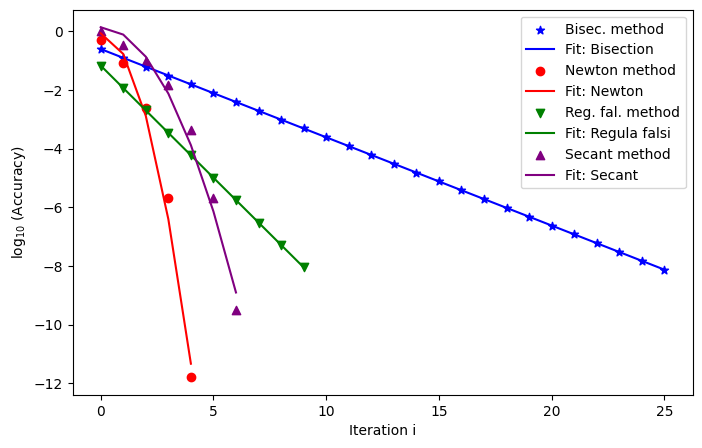

In [15]:
plt.figure(figsize = (8,5))

plt.scatter(input_bl, log_y_bl, marker = "*", color = 'blue', label = "Bisec. method")
plt.plot(input_bl, slope_bl*input_bl + intercept_bl, color='blue', label='Fit: Bisection')

plt.scatter(i_nl, log_y_nl, marker = "o" , color = 'red', label='Newton method')
plt.plot(i_nl, slope_nl*input_nl + intercept_nl, color='red', label='Fit: Newton')

plt.scatter(input_rfl, log_y_rfl, marker = "v", color = 'green', label='Reg. fal. method')
plt.plot(input_rfl, slope_rfl*input_rfl + intercept_rfl, color='green', label='Fit: Regula falsi')

plt.scatter(i_sl, log_y_sl, marker = "^", color = 'purple', label='Secant method')
plt.plot(i_sl, slope_sl*input_sl + intercept_sl, color='purple', label='Fit: Secant')

plt.xlabel("Iteration i")
plt.ylabel(r"$\mathrm{log}_{10}$ (Accuracy)")
plt.legend()
plt.show()